# Point-cloud WDL analysis

3D analog of `MNIST_WDL_lista_search_analysis.ipynb`.

Loads:
- a dataset prepared by `prepare_pointcloud_ot.py` (base measure on $[0,1]^3$, plus per-class transport maps)
- a checkpoint trained by `pointcloud_run_experiments.py`

and visualizes:
1. Base measure and example raw point clouds
2. Learned dictionary atoms $T_j$ (3D scatter)
3. Reconstructions $\hat T$ vs. ground-truth maps for a few samples
4. Code statistics (per-class mean codes, sparsity, linear-probe accuracy)

Defaults point at the ModelNet10 six-class uniform-base run used for the main analysis. The commented paths select the chair-base comparison run; change `DATA_DIR` and `RESULTS_DIR` to switch between them.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3d projection)
import numpy as np
import torch
import torch.nn.functional as F

# Resolve paths from either the current repo layout or the legacy nested layout.
HERE = Path.cwd().resolve()
WDL_REPO = None
for parent in [HERE, *HERE.parents]:
    if (parent / "pointcloud").is_dir() and (parent / "mnist" / "pipeline" / "mnist_sae_models.py").exists():
        WDL_REPO = parent
        REPO_ROOT = parent
        break
    nested = parent / "wdl_repo"
    if (nested / "pointcloud").is_dir() and (nested / "mnist" / "pipeline" / "mnist_sae_models.py").exists():
        WDL_REPO = nested
        REPO_ROOT = parent
        break
if WDL_REPO is None:
    raise RuntimeError(
        f"Could not locate WDL repo from cwd={HERE}. "
        "Set WDL_REPO = Path('/path/to/WDL_repo') manually in this cell."
    )
MNIST_PIPELINE = WDL_REPO / "mnist" / "pipeline"
for path_entry in (str(WDL_REPO), str(MNIST_PIPELINE)):
    if path_entry not in sys.path:
        sys.path.insert(0, path_entry)
print("REPO_ROOT     :", REPO_ROOT)
print("WDL_REPO      :", WDL_REPO)
print("MNIST_PIPELINE:", MNIST_PIPELINE)

from mnist_sae_models import DisplacementFieldSAE, TransportMapSAE, load_model_state
from pointcloud.pipeline.pointcloud_centered_sae import CenteredDisplacementFieldSAE
from pointcloud.pipeline.pointcloud_data import load_with_labels

# Edit these two paths to switch between datasets / runs.
#DATA_DIR    = WDL_REPO / "datasets" / "modelnet10_6cls_chair_ot"
#RESULTS_DIR = WDL_REPO / "pointcloud" / "results" / "modelnet10_6cls_chair"

# Uniform base measure:
DATA_DIR    = WDL_REPO / "datasets" / "modelnet10_6cls_ot"
RESULTS_DIR = WDL_REPO / "pointcloud" / "results" / "modelnet10_6cls_uniform_centered_cosine_lrmin5e-6"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print("Device:", DEVICE)
print("Data:  ", DATA_DIR)
print("Results:", RESULTS_DIR)


REPO_ROOT     : REPO_ROOT
WDL_REPO      : REPO_ROOT
MNIST_PIPELINE: REPO_ROOT/mnist/pipeline
Device: mps
Data:   REPO_ROOT/datasets/modelnet10_6cls_ot
Results: REPO_ROOT/pointcloud/results/modelnet10_6cls_uniform_centered_cosine_lrmin5e-6


## 1. Inspect the dataset

In [2]:
with open(DATA_DIR / "metadata.json") as f:
    meta = json.load(f)
print(json.dumps(meta, indent=2))

{
  "format": "pointcloud_ot_maps",
  "version": 1,
  "dataset": "modelnet10",
  "parameters": {
    "base_supp_size": 1000,
    "cloud_supp_size": 1024,
    "max_per_class": 300,
    "samples_per_mesh": 1,
    "split": "train",
    "ot_method": "emd",
    "seed": 42,
    "base_source": "uniform",
    "base_class": null,
    "base_mesh_index": 0,
    "base_source_id": null
  },
  "classes": [
    "bed",
    "chair",
    "monitor",
    "sofa",
    "table",
    "toilet"
  ],
  "class_counts": {
    "bed": 300,
    "chair": 300,
    "monitor": 300,
    "sofa": 300,
    "table": 300,
    "toilet": 300
  },
  "elapsed_seconds": 522.9671261310577
}


In [3]:
X, maps, labels, class_names = load_with_labels(DATA_DIR)
print(f"X: {tuple(X.shape)}, maps: {tuple(maps.shape)}, classes: {class_names}")

  Loaded class 'bed' (label=0): 300 maps
  Loaded class 'chair' (label=1): 300 maps
  Loaded class 'monitor' (label=2): 300 maps
  Loaded class 'sofa' (label=3): 300 maps
  Loaded class 'table' (label=4): 300 maps
  Loaded class 'toilet' (label=5): 300 maps
Total: 1800 labeled maps, n=1000, dim=3
X: (1000, 3), maps: (1800, 1000, 3), classes: ['bed', 'chair', 'monitor', 'sofa', 'table', 'toilet']


REPO_ROOT/pointcloud/pipeline/pointcloud_data.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X = torch.load(data_dir / "base_measure.pt", map_location="cpu").float()


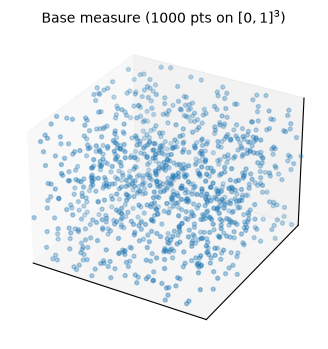

In [4]:
def scatter3d(ax, pts, s=4, alpha=0.6, c=None, title=None, **scatter_kwargs):
    pts = np.asarray(pts)
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=s, alpha=alpha, c=c, **scatter_kwargs)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    if title:
        ax.set_title(title, fontsize=10)

# Base measure
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection="3d")
scatter3d(ax, X, s=8, alpha=0.7, title=f"Base measure ({X.shape[0]} pts on $[0,1]^3$)")
plt.show()

<notebook>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pts = torch.load(p).numpy()


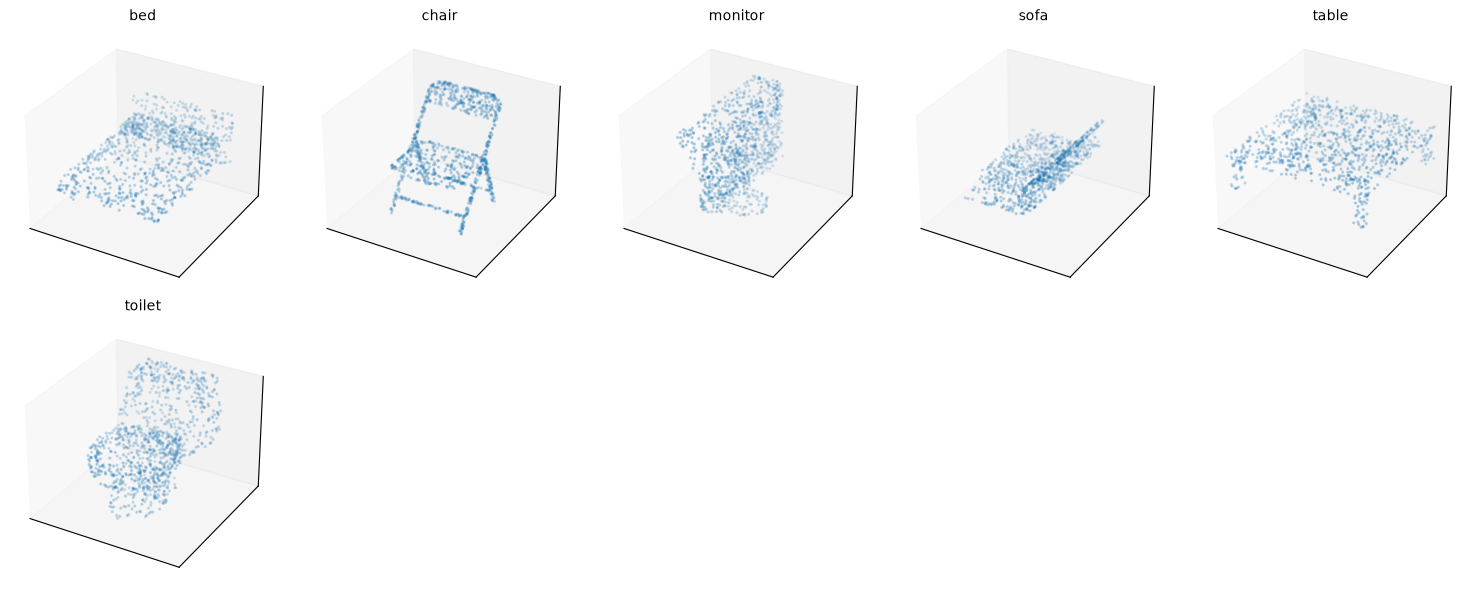

In [5]:
# One example cloud per class (saved by prepare_pointcloud_ot.py)
raw_dir = DATA_DIR / "_raw_examples"
raw_files = sorted(raw_dir.glob("*.pt")) if raw_dir.exists() else []
n = len(raw_files)
if n:
    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig = plt.figure(figsize=(3 * cols, 3 * rows))
    for i, p in enumerate(raw_files):
        ax = fig.add_subplot(rows, cols, i + 1, projection="3d")
        pts = torch.load(p).numpy()
        scatter3d(ax, pts, s=2, alpha=0.5, title=p.stem)
    plt.tight_layout(); plt.show()
else:
    print("No raw examples saved; rerun prepare_pointcloud_ot.py to populate _raw_examples/")

## 2. Load a trained checkpoint

In [6]:
ckpts = sorted(RESULTS_DIR.glob("*.pt"))
print("Available checkpoints:")
for c in ckpts:
    print("  ", c.name)
assert ckpts, f"No checkpoints in {RESULTS_DIR}; run pointcloud_run_experiments.py first."

# Pick the first (or hand-edit to choose)
CKPT_PATH = ckpts[0]
blob = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
print("\nLoaded:", CKPT_PATH.name)
print("  method =", blob["method"])
print("  eps    =", blob["eps"])
print("  c      =", blob["sparsity_coeff"])
print("  m      =", blob["m"])
print("  lista_steps =", blob["lista_steps"])

Available checkpoints:
   displacement_centered_eps0.025_c0.0001.pt
   displacement_centered_eps0.025_c0.0001_best.pt

Loaded: displacement_centered_eps0.025_c0.0001.pt
  method = displacement_centered
  eps    = 0.025
  c      = 0.0001
  m      = 30
  lista_steps = 20


In [7]:
method = blob["method"]
model_kwargs = dict(
    X=blob["X"].float(),
    m=blob["m"],
    eps=blob["eps"],
    grid_side=10,                  # ignored: grid_points overrides
    grid_points=blob["grid_points"].float(),
    lista_steps=blob["lista_steps"],
    activation_type=blob.get("activation_type", "relu"),
    topk_k=blob.get("topk_k", 3),
    normalize_atoms=True,
    per_atom_gain=True,
    lateral_init="damped_identity",
)
if method == "displacement":
    model = DisplacementFieldSAE(**model_kwargs)
elif method in ("displacement_centered", "centered_displacement"):
    model = CenteredDisplacementFieldSAE(
        **model_kwargs,
        displacement_center=blob["displacement_center"].float(),
    )
else:
    model = TransportMapSAE(**model_kwargs)
load_model_state(model, blob["model_state"])
model = model.to(DEVICE).eval()
print(f"Model loaded: {method}")


Model loaded: displacement_centered


## 3. Visualize the learned atoms

Each atom $T_j$ maps the base measure to a point cloud in $[0,1]^3$. Below we plot $T_j(X)$ as a 3D scatter for every atom.

atoms shape: (30, 1000, 3)


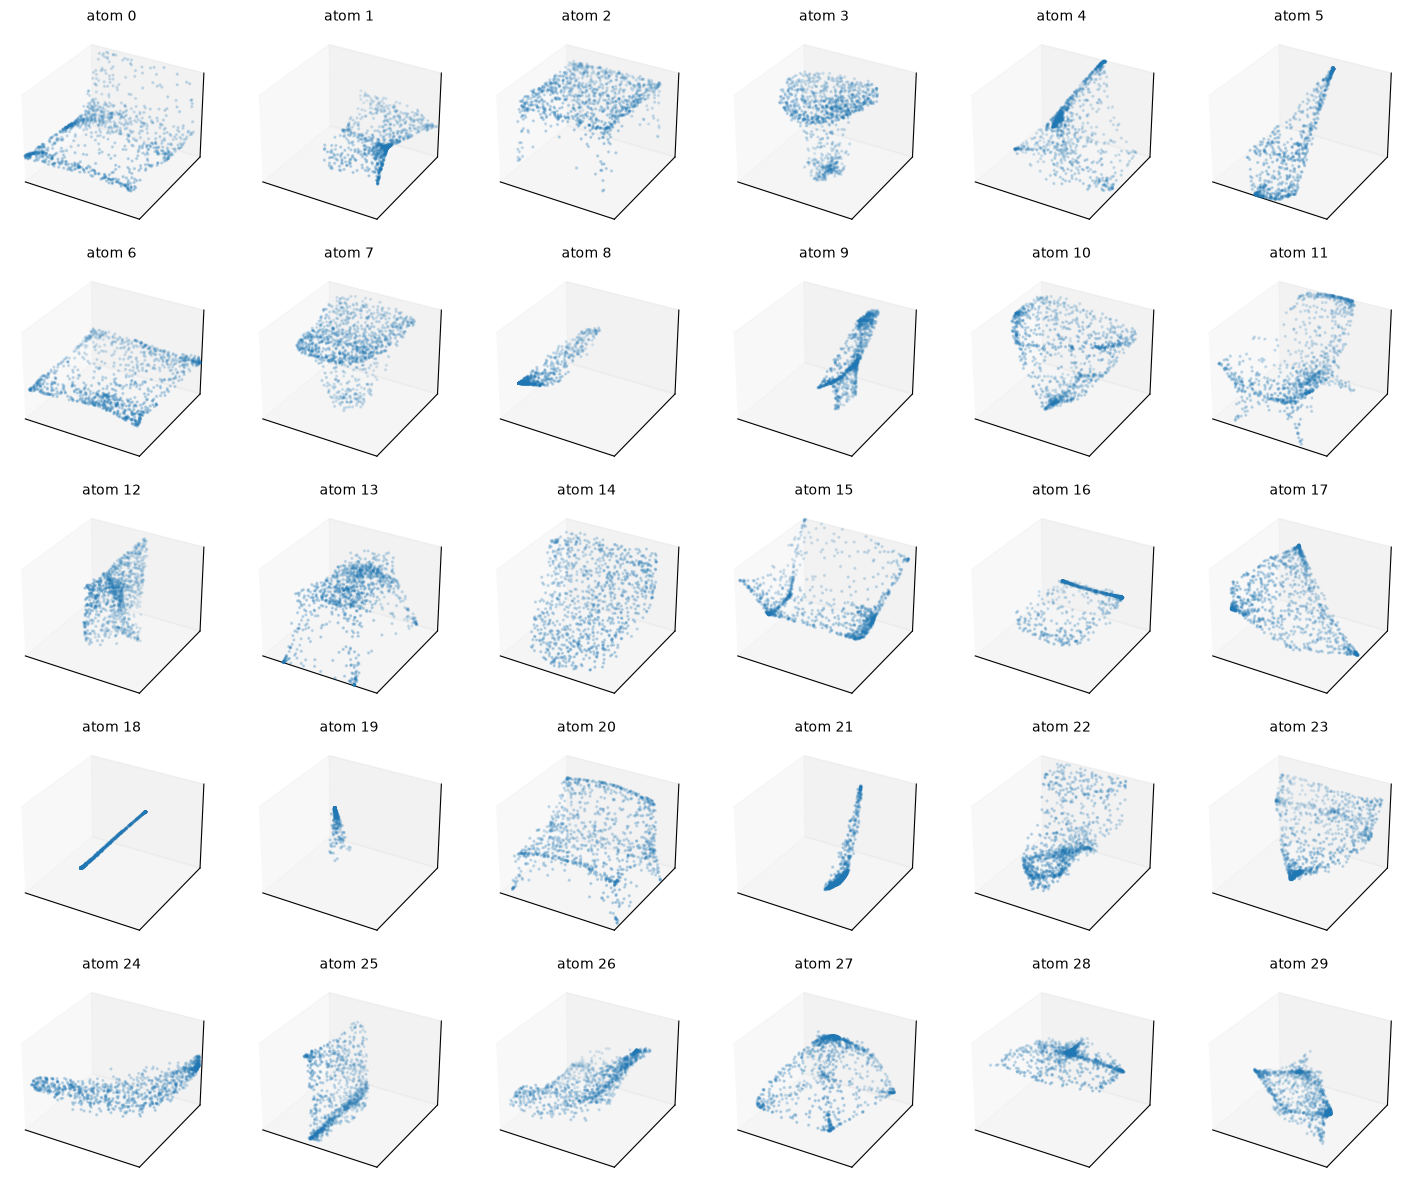

In [8]:
with torch.no_grad():
    atoms = model.atoms_module().cpu().numpy()  # (m, n, 3)
print("atoms shape:", atoms.shape)

m = atoms.shape[0]
cols = 6
rows = (m + cols - 1) // cols
fig = plt.figure(figsize=(2.4 * cols, 2.4 * rows))
for j in range(m):
    ax = fig.add_subplot(rows, cols, j + 1, projection="3d")
    scatter3d(ax, atoms[j], s=2, alpha=0.5, title=f"atom {j}")
plt.tight_layout(); plt.show()

## 4. Reconstructions vs. ground truth

Pick one example per class; plot the ground-truth transport map alongside the model's reconstruction.

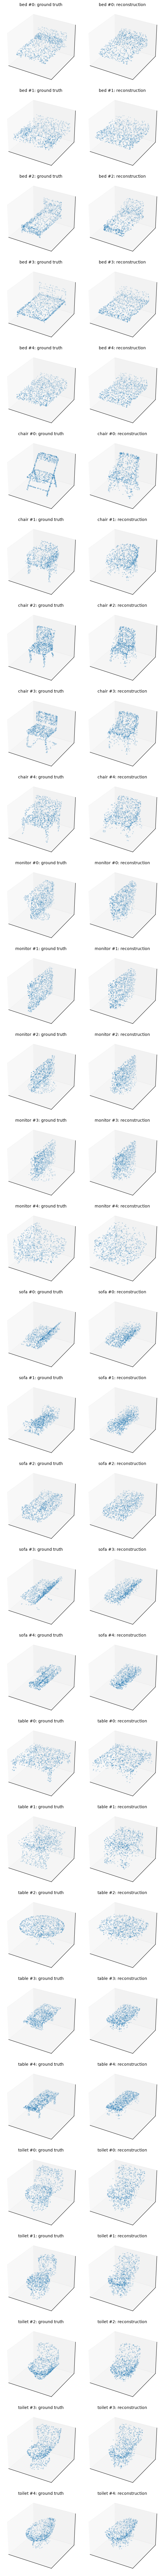

             bed #0: recon=0.0013  active_atoms=19/30
             bed #1: recon=0.0016  active_atoms=21/30
             bed #2: recon=0.0018  active_atoms=23/30
             bed #3: recon=0.0012  active_atoms=23/30
             bed #4: recon=0.0009  active_atoms=21/30
           chair #0: recon=0.0033  active_atoms=25/30
           chair #1: recon=0.0027  active_atoms=24/30
           chair #2: recon=0.0014  active_atoms=22/30
           chair #3: recon=0.0027  active_atoms=24/30
           chair #4: recon=0.0018  active_atoms=20/30
         monitor #0: recon=0.0019  active_atoms=23/30
         monitor #1: recon=0.0013  active_atoms=25/30
         monitor #2: recon=0.0013  active_atoms=21/30
         monitor #3: recon=0.0015  active_atoms=21/30
         monitor #4: recon=0.0034  active_atoms=24/30
            sofa #0: recon=0.0011  active_atoms=21/30
            sofa #1: recon=0.0010  active_atoms=21/30
            sofa #2: recon=0.0013  active_atoms=22/30
            sofa #3: recon=0

In [9]:
N_PER_CLASS = 5  # examples per class to visualize

examples = []
for cls_idx, cls in enumerate(class_names):
    candidates = (labels == cls_idx).nonzero(as_tuple=True)[0]
    for i in range(min(N_PER_CLASS, len(candidates))):
        examples.append((cls, int(candidates[i])))

with torch.no_grad():
    T_in = torch.stack([maps[i] for _, i in examples]).float().to(DEVICE)
    T_hat, lam = model(T_in)
    T_in_np = T_in.cpu().numpy()
    T_hat_np = T_hat.cpu().numpy()
    lam_np = lam.cpu().numpy()

n_ex = len(examples)
fig = plt.figure(figsize=(6, 3 * n_ex))
for k, (cls, _) in enumerate(examples):
    ax_gt   = fig.add_subplot(n_ex, 2, 2 * k + 1, projection="3d")
    ax_hat  = fig.add_subplot(n_ex, 2, 2 * k + 2, projection="3d")
    ex_num  = k % N_PER_CLASS
    scatter3d(ax_gt,  T_in_np[k],  s=2, alpha=0.5, title=f"{cls} #{ex_num}: ground truth")
    scatter3d(ax_hat, T_hat_np[k], s=2, alpha=0.5, title=f"{cls} #{ex_num}: reconstruction")
plt.tight_layout(); plt.show()

# Per-example reconstruction error
err = ((T_in - T_hat) ** 2).sum(dim=(1, 2)).cpu().numpy() / (2 * model.n)
for k, ((cls, _), e, l) in enumerate(zip(examples, err, lam_np)):
    n_active = int((l > 0).sum())
    ex_num   = k % N_PER_CLASS
    print(f"  {cls:>14s} #{ex_num}: recon={e:.4f}  active_atoms={n_active}/{model.m}")


In [10]:
# Mean reconstruction error over the full dataset (and per class)
@torch.no_grad()
def recon_errors(model, maps, batch=256):
    out = []
    for i in range(0, maps.shape[0], batch):
        T = maps[i:i + batch].float().to(DEVICE)
        T_hat, _ = model(T)
        e = ((T - T_hat) ** 2).sum(dim=(1, 2)) / (2 * model.n)
        out.append(e.cpu())
    return torch.cat(out, dim=0)

errs = recon_errors(model, maps).numpy()
print(f"Overall: mean={errs.mean():.5f}  median={np.median(errs):.5f}  "
      f"std={errs.std():.5f}  min={errs.min():.5f}  max={errs.max():.5f}  "
      f"(N={len(errs)})")

print("\nPer class:")
lab_np = labels.numpy()
for k, cls in enumerate(class_names):
    e_k = errs[lab_np == k]
    print(f"  {cls:>14s}: mean={e_k.mean():.5f}  median={np.median(e_k):.5f}  "
          f"(n={len(e_k)})")

Overall: mean=0.00179  median=0.00160  std=0.00097  min=0.00041  max=0.01092  (N=1800)

Per class:
             bed: mean=0.00134  median=0.00119  (n=300)
           chair: mean=0.00247  median=0.00233  (n=300)
         monitor: mean=0.00156  median=0.00131  (n=300)
            sofa: mean=0.00120  median=0.00106  (n=300)
           table: mean=0.00202  median=0.00160  (n=300)
          toilet: mean=0.00214  median=0.00203  (n=300)


## 5. Code statistics

Encode all maps, then look at:
- mean code per class (which atoms each class activates)
- sparsity per sample
- linear-probe classification accuracy on the codes

In [11]:
@torch.no_grad()
def encode_all(model, maps, batch=256):
    out = []
    for i in range(0, maps.shape[0], batch):
        T = maps[i:i + batch].float().to(DEVICE)
        _, lam = model(T)
        out.append(lam.cpu())
    return torch.cat(out, dim=0)

codes = encode_all(model, maps)
print("codes:", tuple(codes.shape))

codes: (1800, 30)


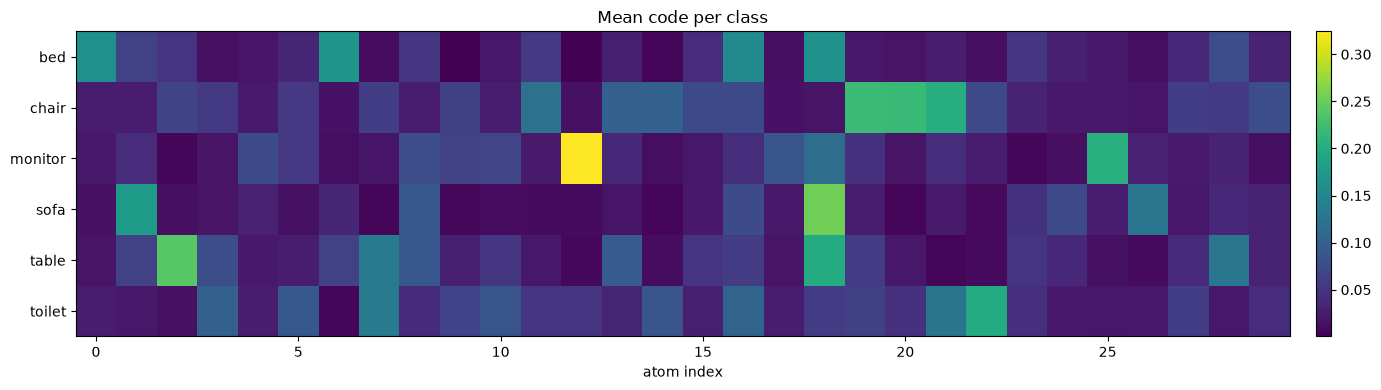

In [12]:
# Mean code per class
K = len(class_names)
mean_code = torch.stack([codes[labels == k].mean(dim=0) for k in range(K)]).numpy()
fig, ax = plt.subplots(figsize=(0.4 * mean_code.shape[1] + 2, 0.5 * K + 1))
im = ax.imshow(mean_code, aspect="auto", cmap="viridis")
ax.set_xlabel("atom index")
ax.set_yticks(range(K))
ax.set_yticklabels(class_names)
ax.set_title("Mean code per class")
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout(); plt.show()

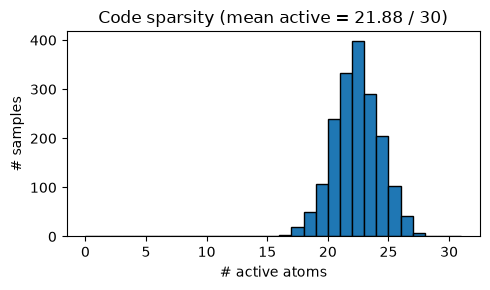

In [13]:
# Sparsity
n_active = (codes > 0).sum(dim=1).numpy()
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(n_active, bins=range(0, model.m + 2), edgecolor="black")
ax.set_xlabel("# active atoms")
ax.set_ylabel("# samples")
ax.set_title(f"Code sparsity (mean active = {n_active.mean():.2f} / {model.m})")
plt.tight_layout(); plt.show()

In [14]:
# Linear probe -- 90/10 split, ridge-regularized least squares
rng = np.random.RandomState(0)
perm = rng.permutation(len(codes))
split = int(0.9 * len(codes))
tr, te = perm[:split], perm[split:]

Xtr = codes[tr]
Xte = codes[te]
ytr = labels[tr]
yte = labels[te]

mu = Xtr.mean(0, keepdim=True)
sd = Xtr.std(0, keepdim=True).clamp(min=1e-6)
Xtr = (Xtr - mu) / sd
Xte = (Xte - mu) / sd
Xtr = torch.cat([Xtr, torch.ones(Xtr.shape[0], 1)], dim=1)
Xte = torch.cat([Xte, torch.ones(Xte.shape[0], 1)], dim=1)

Y = F.one_hot(ytr, num_classes=K).float()
ridge = 1e-3
G = Xtr.T @ Xtr
reg = ridge * torch.eye(G.shape[0]); reg[-1, -1] = 0.0
W = torch.linalg.solve(G + reg, Xtr.T @ Y)

tr_acc = ((Xtr @ W).argmax(1) == ytr).float().mean().item()
te_acc = ((Xte @ W).argmax(1) == yte).float().mean().item()
print(f"Linear-probe train acc = {tr_acc:.3f}")
print(f"Linear-probe test  acc = {te_acc:.3f}")

Linear-probe train acc = 0.968
Linear-probe test  acc = 0.972


## 6. PCA of codes

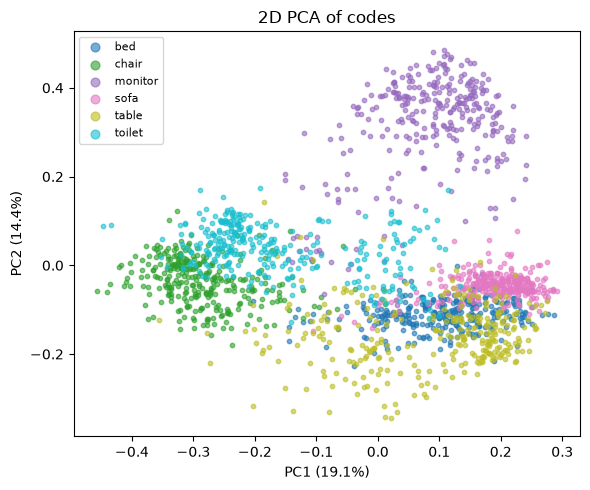

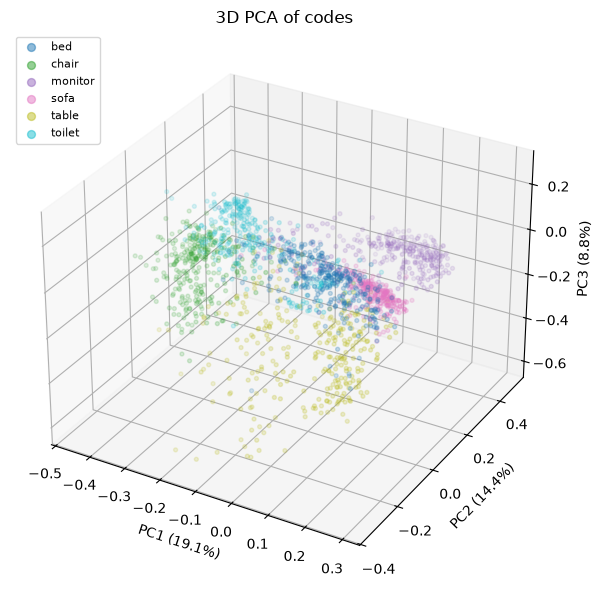

In [15]:
# PCA of codes — 2D and 3D scatter coloured by class
C = codes.numpy()
C_centered = C - C.mean(0)
_, S, Vt = np.linalg.svd(C_centered, full_matrices=False)
pcs = C_centered @ Vt.T          # (N, m) projected scores
var = S**2 / (S**2).sum()

lab = labels.numpy()
cmap = plt.colormaps.get_cmap("tab10").resampled(K)

# 2D
fig, ax = plt.subplots(figsize=(6, 5))
for k, cls in enumerate(class_names):
    mask = lab == k
    ax.scatter(pcs[mask, 0], pcs[mask, 1], s=10, alpha=0.6,
               color=cmap(k), label=cls)
ax.set_xlabel(f"PC1 ({var[0]:.1%})")
ax.set_ylabel(f"PC2 ({var[1]:.1%})")
ax.set_title("2D PCA of codes")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()

# 3D
fig = plt.figure(figsize=(7, 6))
ax3 = fig.add_subplot(111, projection="3d")
for k, cls in enumerate(class_names):
    mask = lab == k
    ax3.scatter(pcs[mask, 0], pcs[mask, 1], pcs[mask, 2],
                s=8, alpha=0.5, color=cmap(k), label=cls)
ax3.set_xlabel(f"PC1 ({var[0]:.1%})")
ax3.set_ylabel(f"PC2 ({var[1]:.1%})")
ax3.set_zlabel(f"PC3 ({var[2]:.1%})")
ax3.set_title("3D PCA of codes")
ax3.legend(markerscale=2, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

## 7. UMAP of codes

REPO_ROOT/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
REPO_ROOT/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


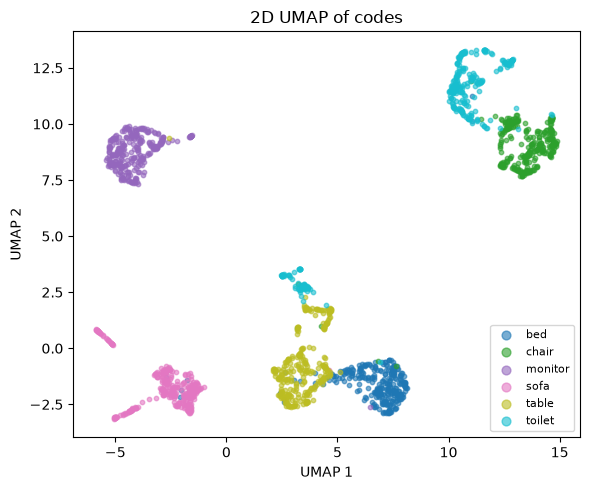

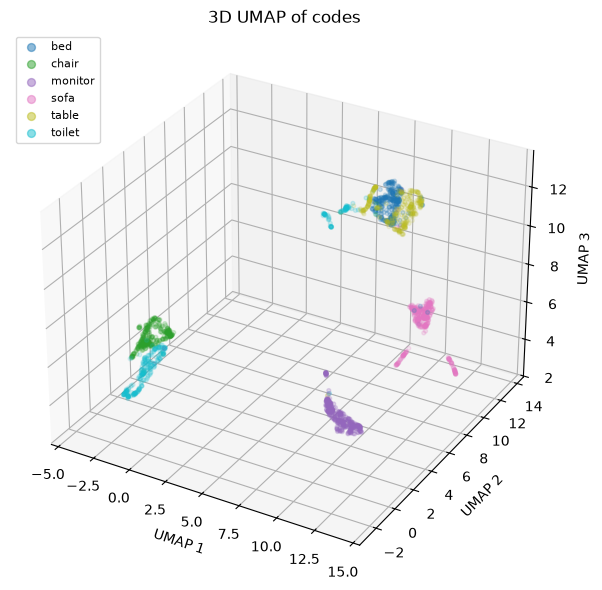

In [16]:
# !pip install umap-learn  # uncomment if needed
import umap

reducer = umap.UMAP(n_components=2, random_state=0, n_neighbors=15, min_dist=0.1)
embedding_2d = reducer.fit_transform(codes.numpy())

reducer3 = umap.UMAP(n_components=3, random_state=0, n_neighbors=15, min_dist=0.1)
embedding_3d = reducer3.fit_transform(codes.numpy())

lab = labels.numpy()
cmap = plt.colormaps.get_cmap("tab10").resampled(K)

# 2D
fig, ax = plt.subplots(figsize=(6, 5))
for k, cls in enumerate(class_names):
    mask = lab == k
    ax.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1],
               s=10, alpha=0.6, color=cmap(k), label=cls)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("2D UMAP of codes")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()

# 3D
fig = plt.figure(figsize=(7, 6))
ax3 = fig.add_subplot(111, projection="3d")
for k, cls in enumerate(class_names):
    mask = lab == k
    ax3.scatter(embedding_3d[mask, 0], embedding_3d[mask, 1], embedding_3d[mask, 2],
                s=8, alpha=0.5, color=cmap(k), label=cls)
ax3.set_xlabel("UMAP 1")
ax3.set_ylabel("UMAP 2")
ax3.set_zlabel("UMAP 3")
ax3.set_title("3D UMAP of codes")
ax3.legend(markerscale=2, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

## 8. Linear classifier — PC ablation

   1 PCs — train=0.336  test=0.306
   2 PCs — train=0.590  test=0.561
   3 PCs — train=0.783  test=0.772
   4 PCs — train=0.823  test=0.822
   5 PCs — train=0.840  test=0.828
   6 PCs — train=0.846  test=0.828
   7 PCs — train=0.864  test=0.822
   8 PCs — train=0.869  test=0.822
   9 PCs — train=0.889  test=0.844
  10 PCs — train=0.898  test=0.861
  11 PCs — train=0.917  test=0.872
  12 PCs — train=0.923  test=0.878
  13 PCs — train=0.923  test=0.872
  14 PCs — train=0.929  test=0.872
  15 PCs — train=0.943  test=0.894
  16 PCs — train=0.956  test=0.933
  17 PCs — train=0.955  test=0.939
  18 PCs — train=0.952  test=0.939
  19 PCs — train=0.954  test=0.939
  20 PCs — train=0.956  test=0.939
  21 PCs — train=0.960  test=0.956
  22 PCs — train=0.962  test=0.956
  23 PCs — train=0.964  test=0.961
  24 PCs — train=0.963  test=0.967
  25 PCs — train=0.965  test=0.967
  26 PCs — train=0.965  test=0.967
  27 PCs — train=0.968  test=0.967
  28 PCs — train=0.970  test=0.967
  29 PCs — train=0.9

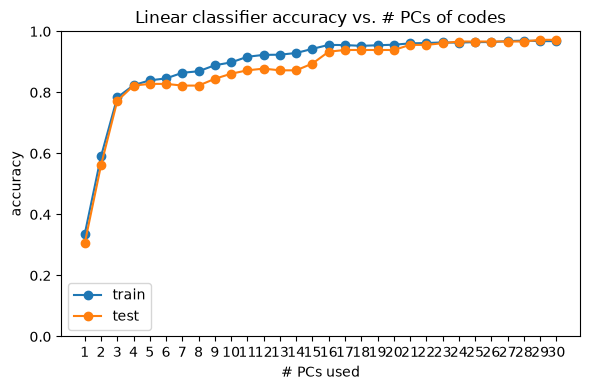

In [17]:
# Reuse the same train/test split from the linear probe cell (perm, split, tr, te, K)
# pcs is (N, m) from the PCA cell

max_pcs = 30
tr_accs, te_accs = [], []

for n_pcs in range(1, max_pcs + 1):
    Xtr_pca = torch.tensor(pcs[tr, :n_pcs], dtype=torch.float32)
    Xte_pca = torch.tensor(pcs[te, :n_pcs], dtype=torch.float32)

    mu = Xtr_pca.mean(0, keepdim=True)
    sd = Xtr_pca.std(0, keepdim=True).clamp(min=1e-6)
    Xtr_pca = (Xtr_pca - mu) / sd
    Xte_pca = (Xte_pca - mu) / sd

    Xtr_b = torch.cat([Xtr_pca, torch.ones(Xtr_pca.shape[0], 1)], dim=1)
    Xte_b = torch.cat([Xte_pca, torch.ones(Xte_pca.shape[0], 1)], dim=1)

    Y = F.one_hot(ytr, num_classes=K).float()
    G = Xtr_b.T @ Xtr_b
    reg = 1e-3 * torch.eye(G.shape[0]); reg[-1, -1] = 0.0
    W = torch.linalg.solve(G + reg, Xtr_b.T @ Y)

    tr_accs.append(((Xtr_b @ W).argmax(1) == ytr).float().mean().item())
    te_accs.append(((Xte_b @ W).argmax(1) == yte).float().mean().item())
    print(f"  {n_pcs:2d} PCs — train={tr_accs[-1]:.3f}  test={te_accs[-1]:.3f}")

xs = range(1, max_pcs + 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(xs, tr_accs, marker="o", label="train")
ax.plot(xs, te_accs, marker="o", label="test")
ax.set_xlabel("# PCs used")
ax.set_ylabel("accuracy")
ax.set_title("Linear classifier accuracy vs. # PCs of codes")
ax.set_xticks(list(xs))
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout(); plt.show()

## 9. Top-N most prevalent code "types"

Bucket each sample by its top-`TOP_K` atoms (by code weight), count the most common
support patterns, and render each bucket's mean code as a per-point linear combination
of atoms: $\hat T = \sum_j w_j\, T_j$. Atoms share the base-measure point ordering, so
this combination is well defined as a point cloud.

Top 8 support patterns (top-3 atoms by weight):
  (1, 18, 26): 148 samples (8.2%)  [sofa:147, bed:1]
  (12, 18, 25): 83 samples (4.6%)  [monitor:83]
  (0, 6, 16): 64 samples (3.6%)  [bed:64]
  (12, 17, 25): 53 samples (2.9%)  [monitor:53]
  (19, 20, 21): 50 samples (2.8%)  [chair:49, toilet:1]
  (1, 8, 18): 49 samples (2.7%)  [sofa:38, table:6, bed:5]
  (0, 6, 18): 45 samples (2.5%)  [bed:45]
  (0, 16, 18): 36 samples (2.0%)  [bed:36]


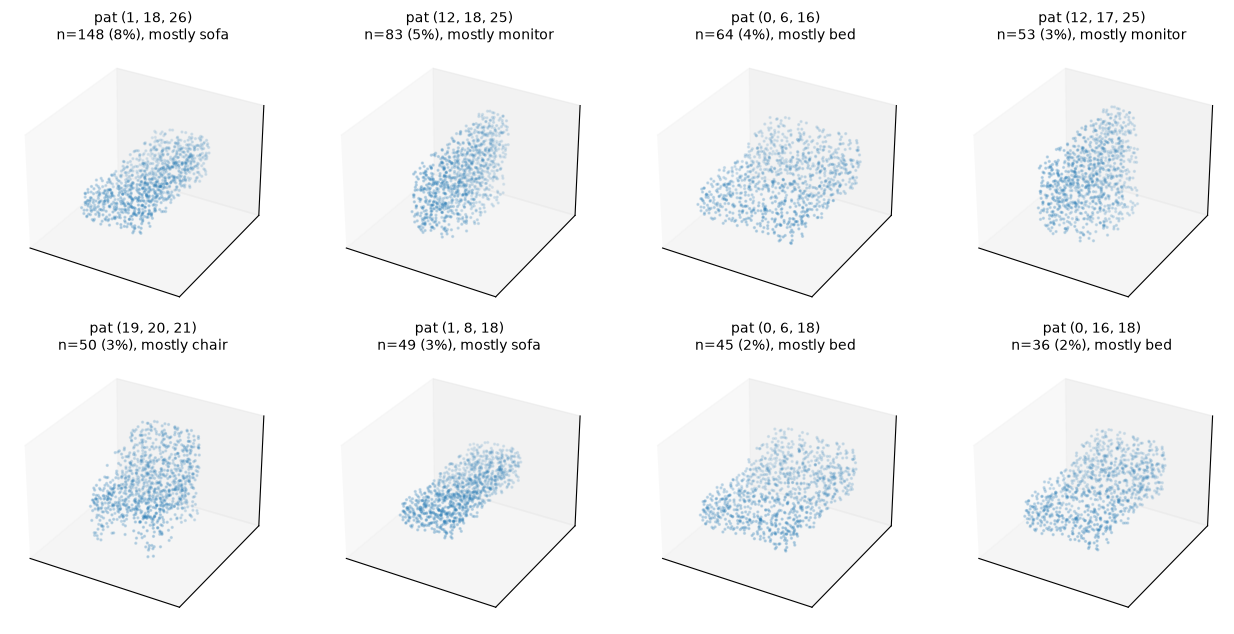

In [18]:
from collections import Counter

TOP_K = 3   # # of top atoms (by weight) that define a "type"
TOP_N = 8   # # of most-common types to visualize

C = codes.numpy()
lab_np = labels.numpy()
N = C.shape[0]

# Sorted tuple of top-K atom indices, per sample
topk_idx = np.argsort(-C, axis=1)[:, :TOP_K]
patterns = [tuple(sorted(map(int, row))) for row in topk_idx]
counts = Counter(patterns)
most_common = counts.most_common(TOP_N)

print(f"Top {TOP_N} support patterns (top-{TOP_K} atoms by weight):")
for pat, cnt in most_common:
    cls_share = Counter(class_names[c] for c in lab_np[[p == pat for p in patterns]])
    breakdown = ", ".join(f"{c}:{n}" for c, n in cls_share.most_common())
    print(f"  {pat}: {cnt} samples ({cnt / N:.1%})  [{breakdown}]")

# Render each bucket's mean code as a linear combo of atoms
cols = min(TOP_N, 4)
rows = (TOP_N + cols - 1) // cols
fig = plt.figure(figsize=(3.2 * cols, 3.2 * rows))
for i, (pat, cnt) in enumerate(most_common):
    mask = np.array([p == pat for p in patterns])
    w = C[mask].mean(0)                                  # mean code in bucket
    w = w / max(w.sum(), 1e-12)                          # renormalize
    cloud = (w[:, None, None] * atoms).sum(0)            # (n, 3)
    top_cls = Counter(class_names[c] for c in lab_np[mask]).most_common(1)[0][0]
    ax = fig.add_subplot(rows, cols, i + 1, projection="3d")
    scatter3d(ax, cloud, s=2, alpha=0.5,
              title=f"pat {pat}\nn={cnt} ({cnt/N:.0%}), mostly {top_cls}")
plt.tight_layout(); plt.show()

### Interactive (plotly) version of the type renderings

Same buckets as above, rendered with `plotly` so you can rotate/zoom each one.
Requires `pip install plotly`.

## 10. Paper figures

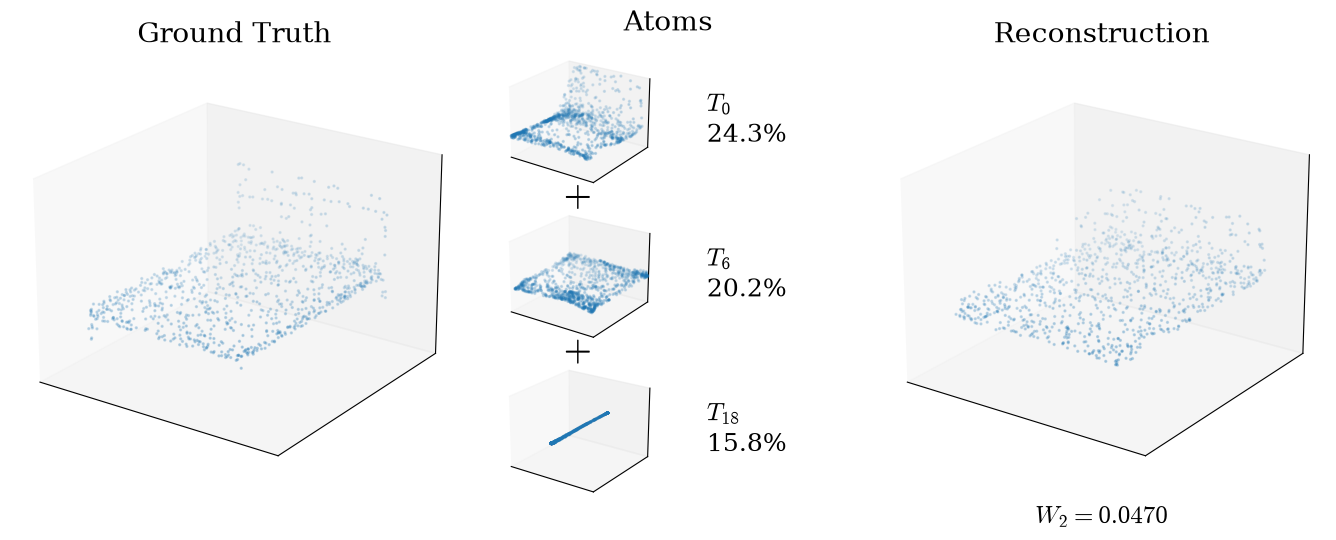

In [19]:
# Figure 1: ground truth | top-3 atoms (with % activation) | reconstruction
import matplotlib.gridspec as gridspec
import ot

SAMPLE_IDX = 3
N_TOP      = 3
ELEV, AZIM = 22, -55

with torch.no_grad():
    T_in = maps[SAMPLE_IDX:SAMPLE_IDX + 1].float().to(DEVICE)
    T_hat, lam = model(T_in)
T_gt_np  = T_in[0].cpu().numpy()
T_hat_np = T_hat[0].cpu().numpy()
w        = lam[0].cpu().numpy()
w_pct    = 100.0 * w / max(w.sum(), 1e-12)
top      = np.argsort(-w)[:N_TOP]
sample_class = class_names[int(labels[SAMPLE_IDX])]

# Wasserstein-2 between GT and reconstruction empirical clouds
n_pts = T_gt_np.shape[0]
a = np.ones(n_pts) / n_pts
M = ot.dist(T_gt_np, T_hat_np, metric="sqeuclidean")
W2 = float(np.sqrt(ot.emd2(a, a, M)))

paper_rc = {
    "font.family":      "serif",
    "mathtext.fontset": "cm",
    "axes.titlesize":   20,
    "font.size":        18,
}

TITLE_FS = 20
LABEL_FS = 18
W2_FS    = 18
PLUS_FS  = 26

with plt.rc_context(paper_rc):
    fig = plt.figure(figsize=(14, 5.8))
    # 4 columns: GT | atoms | labels | reconstruction
    gs = gridspec.GridSpec(
        N_TOP, 4,
        width_ratios=[3, 1.6, 1.2, 3],
        wspace=0.0, hspace=0.0,
        left=0.04, right=0.98, top=0.92, bottom=0.12,
    )

    ax_gt = fig.add_subplot(gs[:, 0], projection="3d")
    scatter3d(ax_gt, T_gt_np, s=2, alpha=0.5, title="Ground Truth")
    ax_gt.set_title("Ground Truth", fontsize=TITLE_FS)
    ax_gt.view_init(elev=ELEV, azim=AZIM)

    atom_axes = []
    for r, j in enumerate(top):
        ax = fig.add_subplot(gs[r, 1], projection="3d")
        scatter3d(ax, atoms[j], s=2, alpha=0.5)
        ax.view_init(elev=ELEV, azim=AZIM)
        atom_axes.append(ax)

        ax_t = fig.add_subplot(gs[r, 2])
        ax_t.axis("off")
        ax_t.text(0.05, 0.5, f"$T_{{{j}}}$\n{w_pct[j]:.1f}%",
                  va="center", ha="left", fontsize=LABEL_FS)

    ax_re = fig.add_subplot(gs[:, 3], projection="3d")
    scatter3d(ax_re, T_hat_np, s=2, alpha=0.5, title="Reconstruction")
    ax_re.set_title("Reconstruction", fontsize=TITLE_FS)
    ax_re.view_init(elev=ELEV, azim=AZIM)

    fig.canvas.draw()

    # "Atoms" header above the atom + label columns
    b_atom0 = gs[0, 1].get_position(fig)
    b_atom1 = gs[0, 2].get_position(fig)
    fig.text(
        0.5 * (b_atom0.x0 + b_atom1.x1), b_atom0.y1 + 0.01,
        "Atoms", ha="center", va="bottom", fontsize=TITLE_FS,
    )

    # + connectors between atom rows
    for r in range(N_TOP - 1):
        b0 = gs[r, 1].get_position(fig)
        b1 = gs[r + 1, 1].get_position(fig)
        fig.text(0.5 * (b0.x0 + b0.x1), 0.5 * (b0.y0 + b1.y1),
                 r"$+$", ha="center", va="center", fontsize=PLUS_FS)

    # W2 caption below the reconstruction subplot
    bbox = ax_re.get_position()
    fig.text((bbox.x0 + bbox.x1) / 2, bbox.y0 - 0.01,
             f"$W_2 = {W2:.4f}$",
             ha="center", va="top", fontsize=W2_FS)

    plt.show()

Selected samples: 1312 and 1648
Shared top-3 atom: T_7


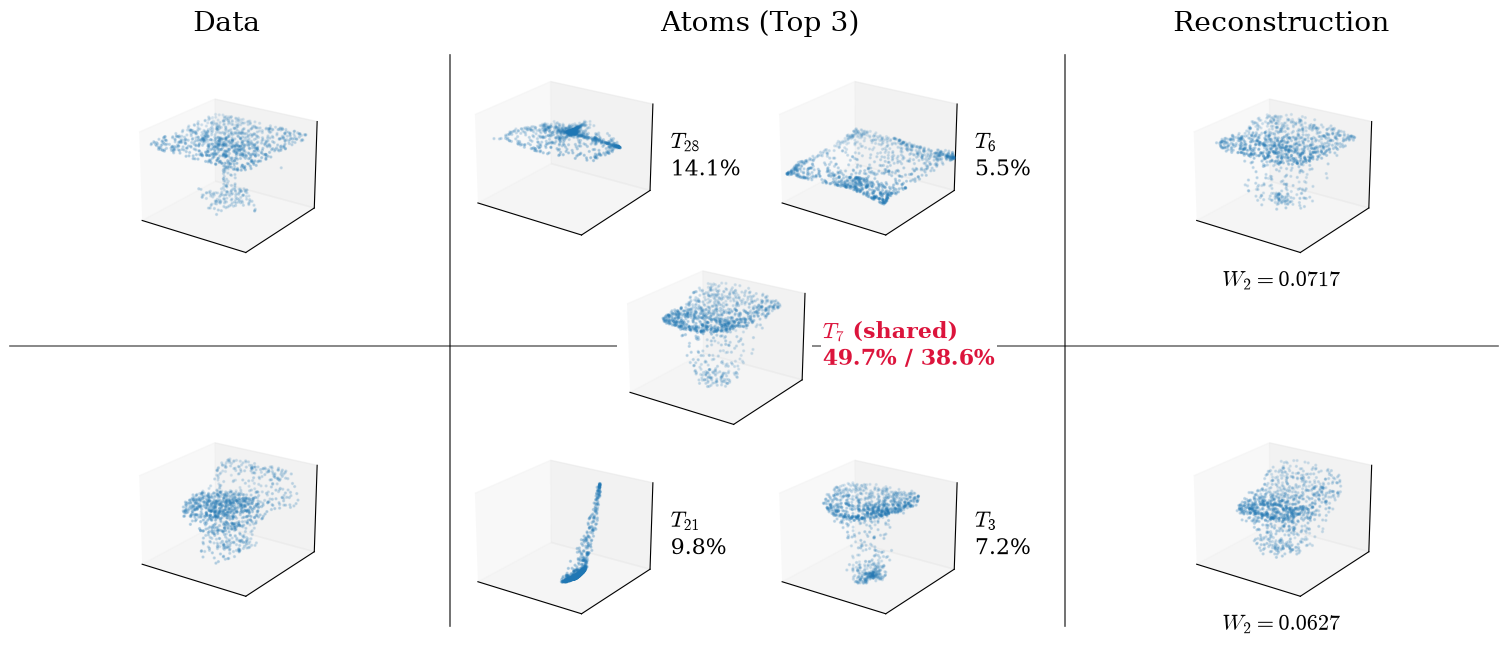

In [20]:
# Figure 1b: two data points sharing one top-3 atom, hourglass atom layout
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import ot

PAIR = (1312, 1648)  # table vs toilet
N_TOP = 3
ELEV, AZIM = 22, -55

paper_rc = {
    "font.family":      "serif",
    "mathtext.fontset": "cm",
    "axes.titlesize":   20,
    "font.size":        18,
}

TITLE_FS = 20
LABEL_FS = 16
W2_FS = 16

SEPARATOR_LW = 1.2
SEPARATOR_ALPHA = 0.65

SHARED_LINE_LW = 1.2
SHARED_LINE_ALPHA = 0.55

# Top data/reconstruction panels move downward and bottom panels move upward.
# Atom positions remain unchanged.
DATA_RECON_INWARD_SHIFT = 0.025

with torch.no_grad():
    T_in = maps[list(PAIR)].float().to(DEVICE)
    T_hat, lam = model(T_in)

T_gt_np = T_in.cpu().numpy()
T_hat_np = T_hat.cpu().numpy()
lam_np = lam.cpu().numpy()

tops = [np.argsort(-lam_np[i])[:N_TOP] for i in range(2)]
top_sets = [set(t) for t in tops]
shared = sorted(top_sets[0].intersection(top_sets[1]))

if len(shared) != 1:
    raise ValueError(
        f"Expected exactly one shared top-{N_TOP} atom, found {shared}"
    )

shared_atom = shared[0]

unique_atoms = [
    [j for j in tops[0] if j != shared_atom],
    [j for j in tops[1] if j != shared_atom],
]

w_pct = [
    100.0 * lam_np[i] / max(lam_np[i].sum(), 1e-12)
    for i in range(2)
]

print(f"Selected samples: {PAIR[0]} and {PAIR[1]}")
print(f"Shared top-{N_TOP} atom: T_{shared_atom}")

with plt.rc_context(paper_rc):
    fig = plt.figure(figsize=(15.5, 7.0))

    # Rows:
    #   top    = first sample's unique atoms
    #   middle = shared atom
    #   bottom = second sample's unique atoms
    #
    # Columns:
    #   Data | small gap | atom | label | atom | label | Reconstruction
    gs = gridspec.GridSpec(
        3,
        7,
        width_ratios=[
            2.75,
            0.08,
            1.35,
            0.58,
            1.35,
            0.58,
            2.75,
        ],
        height_ratios=[1.0, 1.0, 1.0],
        wspace=0.0,
        hspace=-0.03,
        left=0.025,
        right=0.985,
        top=0.875,
        bottom=0.055,
    )

    # Column positions
    b_data = gs[0, 0].get_position(fig)
    b_atoms_left = gs[0, 2].get_position(fig)
    b_atoms_right = gs[0, 5].get_position(fig)
    b_reconstruction = gs[0, 6].get_position(fig)

    # Global column titles
    fig.text(
        (b_data.x0 + b_data.x1) / 2,
        0.905,
        "Data",
        ha="center",
        va="bottom",
        fontsize=TITLE_FS,
    )

    fig.text(
        (b_atoms_left.x0 + b_atoms_right.x1) / 2,
        0.905,
        "Atoms (Top 3)",
        ha="center",
        va="bottom",
        fontsize=TITLE_FS,
    )

    fig.text(
        (b_reconstruction.x0 + b_reconstruction.x1) / 2,
        0.905,
        "Reconstruction",
        ha="center",
        va="bottom",
        fontsize=TITLE_FS,
    )

    # Vertical separators between the three main sections
    left_separator_x = (b_data.x1 + b_atoms_left.x0) / 2
    right_separator_x = (
        b_atoms_right.x1 + b_reconstruction.x0
    ) / 2

    for separator_x in [left_separator_x, right_separator_x]:
        fig.add_artist(
            Line2D(
                [separator_x, separator_x],
                [0.065, 0.88],
                transform=fig.transFigure,
                linewidth=SEPARATOR_LW,
                alpha=SEPARATOR_ALPHA,
                color="black",
                zorder=10,
            )
        )

    # Data and reconstruction panels
    for row, sample_i in zip([0, 2], [0, 1]):
        gt = T_gt_np[sample_i]
        reconstruction = T_hat_np[sample_i]

        n_pts = gt.shape[0]
        masses = np.ones(n_pts) / n_pts

        cost = ot.dist(
            gt,
            reconstruction,
            metric="sqeuclidean",
        )

        W2 = float(
            np.sqrt(
                ot.emd2(
                    masses,
                    masses,
                    cost,
                )
            )
        )

        ax_data = fig.add_subplot(
            gs[row, 0],
            projection="3d",
        )
        scatter3d(
            ax_data,
            gt,
            s=2,
            alpha=0.5,
        )
        ax_data.view_init(
            elev=ELEV,
            azim=AZIM,
        )

        ax_reconstruction = fig.add_subplot(
            gs[row, 6],
            projection="3d",
        )
        scatter3d(
            ax_reconstruction,
            reconstruction,
            s=2,
            alpha=0.5,
        )
        ax_reconstruction.view_init(
            elev=ELEV,
            azim=AZIM,
        )

        # Move only the data and reconstruction panels toward the center.
        inward_shift = (
            -DATA_RECON_INWARD_SHIFT
            if row == 0
            else DATA_RECON_INWARD_SHIFT
        )

        data_bbox = ax_data.get_position()
        ax_data.set_position(
            [
                data_bbox.x0,
                data_bbox.y0 + inward_shift,
                data_bbox.width,
                data_bbox.height,
            ]
        )

        reconstruction_bbox = ax_reconstruction.get_position()
        ax_reconstruction.set_position(
            [
                reconstruction_bbox.x0,
                reconstruction_bbox.y0 + inward_shift,
                reconstruction_bbox.width,
                reconstruction_bbox.height,
            ]
        )

        # Position the W2 label relative to the shifted reconstruction axis.
        reconstruction_bbox = ax_reconstruction.get_position()
        fig.text(
            (
                reconstruction_bbox.x0
                + reconstruction_bbox.x1
            ) / 2,
            reconstruction_bbox.y0 + 0.002,
            f"$W_2 = {W2:.4f}$",
            ha="center",
            va="top",
            fontsize=W2_FS,
        )

    # Top row: unique atoms for first sample
    for atom_col, label_col, j in zip(
        [2, 4],
        [3, 5],
        unique_atoms[0],
    ):
        ax_atom = fig.add_subplot(
            gs[0, atom_col],
            projection="3d",
        )
        scatter3d(
            ax_atom,
            atoms[j],
            s=2,
            alpha=0.5,
        )
        ax_atom.view_init(
            elev=ELEV,
            azim=AZIM,
        )

        ax_label = fig.add_subplot(gs[0, label_col])
        ax_label.axis("off")
        ax_label.text(
            0.02,
            0.5,
            f"$T_{{{j}}}$\n{w_pct[0][j]:.1f}%",
            va="center",
            ha="left",
            fontsize=LABEL_FS,
        )

    # Middle row: shared atom with the same width as the other atoms
    shared_gs = gridspec.GridSpecFromSubplotSpec(
        1,
        4,
        subplot_spec=gs[1, 2:6],
        width_ratios=[
            0.965,
            1.35,
            0.58,
            0.965,
        ],
        wspace=0.0,
    )

    ax_shared = fig.add_subplot(
        shared_gs[0, 1],
        projection="3d",
    )
    scatter3d(
        ax_shared,
        atoms[shared_atom],
        s=2,
        alpha=0.5,
    )
    ax_shared.view_init(
        elev=ELEV,
        azim=AZIM,
    )

    # Ensure the horizontal line is hidden behind the shared atom panel.
    ax_shared.set_zorder(3)
    ax_shared.patch.set_facecolor("white")
    ax_shared.patch.set_alpha(1.0)

    ax_shared_label = fig.add_subplot(shared_gs[0, 2])
    ax_shared_label.axis("off")
    ax_shared_label.set_zorder(3)

    # Keep the text readable over the horizontal line.
    ax_shared_label.text(
        0.02,
        0.5,
        f"$T_{{{shared_atom}}}$ (shared)\n"
        f"{w_pct[0][shared_atom]:.1f}% / "
        f"{w_pct[1][shared_atom]:.1f}%",
        va="center",
        ha="left",
        fontsize=LABEL_FS,
        color="crimson",
        fontweight="bold",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "pad": 1.5,
        },
    )

    # Bottom row: unique atoms for second sample
    for atom_col, label_col, j in zip(
        [2, 4],
        [3, 5],
        unique_atoms[1],
    ):
        ax_atom = fig.add_subplot(
            gs[2, atom_col],
            projection="3d",
        )
        scatter3d(
            ax_atom,
            atoms[j],
            s=2,
            alpha=0.5,
        )
        ax_atom.view_init(
            elev=ELEV,
            azim=AZIM,
        )

        ax_label = fig.add_subplot(gs[2, label_col])
        ax_label.axis("off")
        ax_label.text(
            0.02,
            0.5,
            f"$T_{{{j}}}$\n{w_pct[1][j]:.1f}%",
            va="center",
            ha="left",
            fontsize=LABEL_FS,
        )

    # Force Matplotlib to finalize the subplot positions before placing
    # the horizontal line.
    fig.canvas.draw()

    shared_bbox = ax_shared.get_position()
    shared_line_y = (
        shared_bbox.y0 + shared_bbox.y1
    ) / 2

        # Horizontal line across the entire figure, behind the shared atom
    # image and its text.
    fig.add_artist(
        Line2D(
            [0.025, 0.985],
            [shared_line_y, shared_line_y],
            transform=fig.transFigure,
            linewidth=SHARED_LINE_LW,
            alpha=SHARED_LINE_ALPHA,
            color="black",
            zorder=1,
        )
    )

    plt.show()

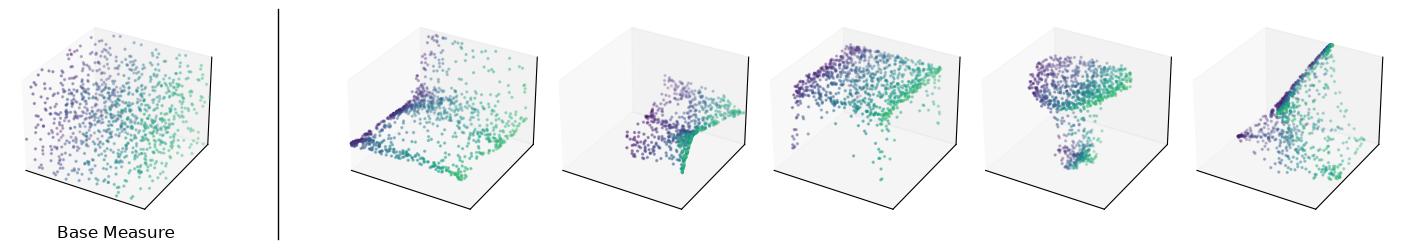

In [21]:
# Figure 2: base measure | divider | row of selected atoms (with point-correspondence colors)
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines

ATOM_IDS = [0, 1, 2, 3, 4]   # which atoms to show; edit freely
n_atoms  = len(ATOM_IDS)

# Per-point colors from base-measure coordinates, using truncated viridis: purple to green without yellow.
# Atoms preserve the base ordering, so the i-th point keeps the same color in every panel.
X_np = X.detach().cpu().numpy() if hasattr(X, "detach") else np.asarray(X)
color_value = X_np[:, 0]
color_value = (color_value - color_value.min()) / (color_value.max() - color_value.min() + 1e-12)
colors = plt.cm.viridis(0.05 + 0.65 * color_value)

fig = plt.figure(figsize=(2.4 * (n_atoms + 1), 2.8))
gs_outer = gridspec.GridSpec(1, 2, width_ratios=[1, n_atoms],
                             wspace=0.18,
                             left=0.02, right=0.98, top=0.95, bottom=0.12)

# Base measure (left)
ax_base = fig.add_subplot(gs_outer[0, 0], projection="3d")
scatter3d(ax_base, X, s=2, alpha=0.7, c=colors)

# Atoms row (right) — tight against each other, same per-point colors
gs_atoms = gridspec.GridSpecFromSubplotSpec(
    1, n_atoms, subplot_spec=gs_outer[0, 1], wspace=0.0
)
atom_axes = []
for k, j in enumerate(ATOM_IDS):
    ax = fig.add_subplot(gs_atoms[0, k], projection="3d")
    scatter3d(ax, atoms[j], s=2, alpha=0.7, c=colors)
    atom_axes.append(ax)

# Vertical divider in figure coords, between base and atoms
fig.canvas.draw()
x_div = 0.5 * (ax_base.get_position().x1 + atom_axes[0].get_position().x0)
fig.add_artist(mlines.Line2D([x_div, x_div], [0.10, 0.92],
                              color="black", lw=1.0,
                              transform=fig.transFigure))

# "Base Measure" caption below the base-measure subplot
bbox = ax_base.get_position()
fig.text((bbox.x0 + bbox.x1) / 2, bbox.y0 - 0.01, "Base Measure",
         ha="center", va="top", fontsize=12)

plt.show()

Lowest-error examples among 1800 clouds:
  #1346     table  err=0.000411  T_18=32.8%, T_8=12.8%, T_1=10.4%
  # 744   monitor  err=0.000451  T_18=26.5%, T_12=15.3%, T_8=10.8%
  #1315     table  err=0.000455  T_18=32.6%, T_8=11.2%, T_1=10.0%
  #1082      sofa  err=0.000478  T_18=35.9%, T_1=13.7%, T_8=12.1%
  # 721   monitor  err=0.000490  T_18=23.7%, T_12=22.6%, T_9=9.2%
  # 951      sofa  err=0.000493  T_18=32.7%, T_1=15.0%, T_8=11.3%


<notebook>:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


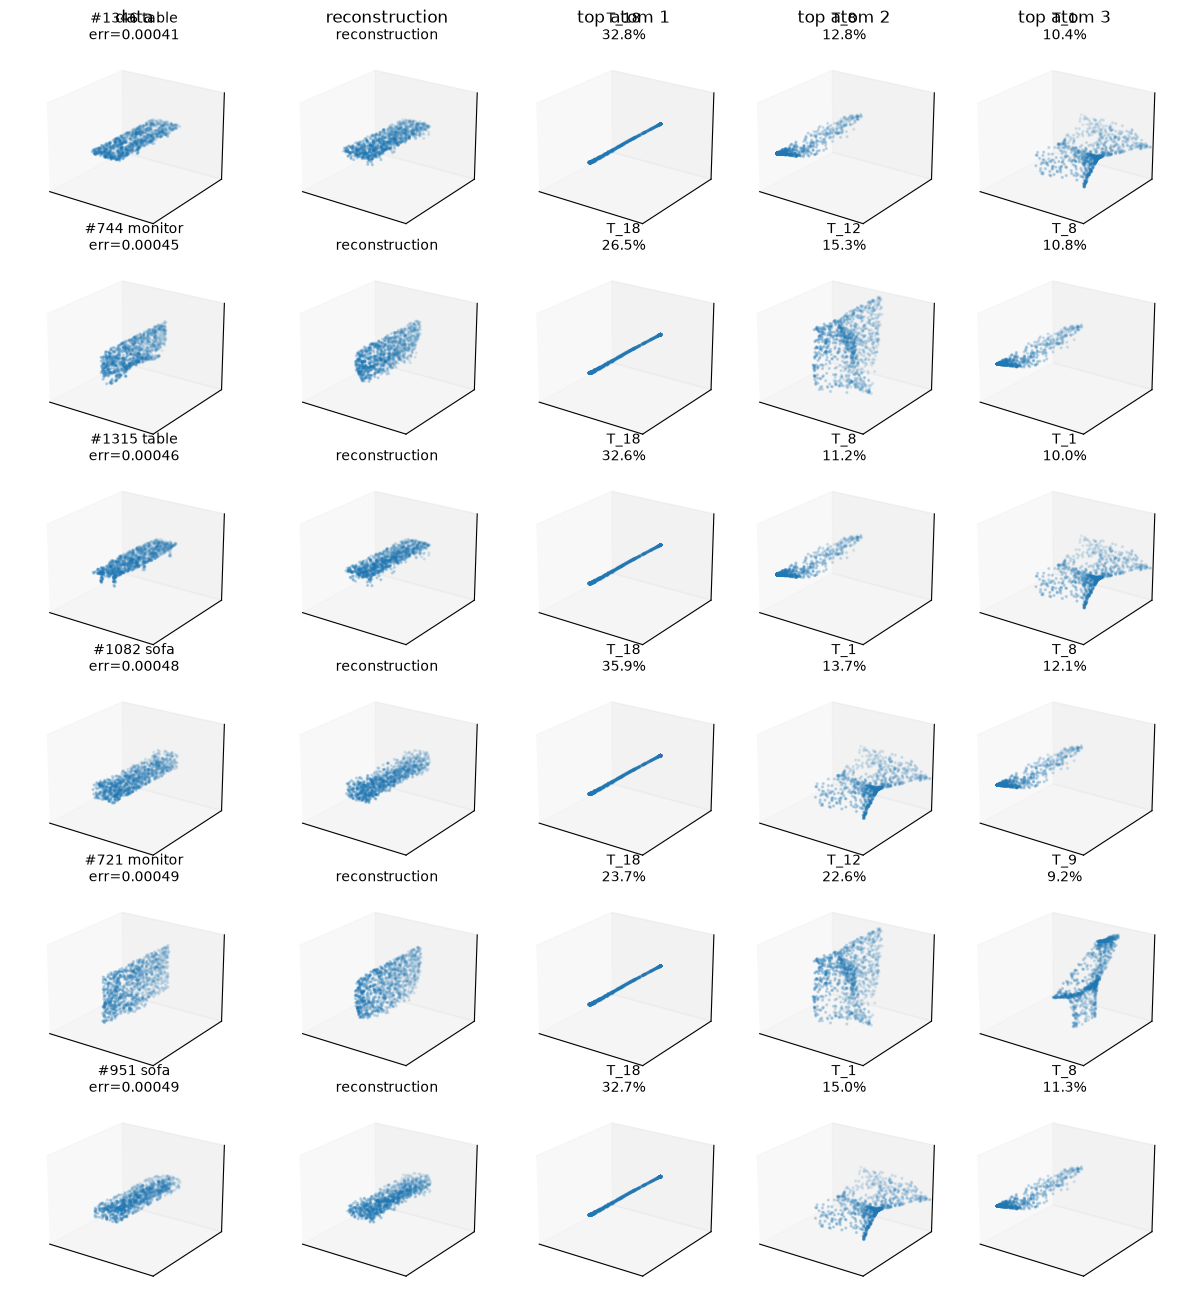

In [22]:
# Lowest-error reconstructions with top atoms
LOWEST_N = 6
N_TOP = 3
ELEV, AZIM = 22, -55

lowest_idx = np.argsort(errs)[:LOWEST_N]

with torch.no_grad():
    T_in = maps[lowest_idx].float().to(DEVICE)
    T_hat, lam = model(T_in)

T_gt_np = T_in.cpu().numpy()
T_hat_np = T_hat.cpu().numpy()
lam_np = lam.cpu().numpy()

print(f"Lowest-error examples among {len(errs)} clouds:")
for row, sample_idx in enumerate(lowest_idx):
    cls = class_names[int(labels[sample_idx])]
    top = np.argsort(-lam_np[row])[:N_TOP]
    top_txt = ", ".join(f"T_{j}={100 * lam_np[row, j] / max(lam_np[row].sum(), 1e-12):.1f}%" for j in top)
    print(f"  #{int(sample_idx):4d}  {cls:>8s}  err={errs[sample_idx]:.6f}  {top_txt}")

fig = plt.figure(figsize=(3.0 * (2 + N_TOP), 2.7 * LOWEST_N))
gs = fig.add_gridspec(
    LOWEST_N,
    2 + N_TOP,
    width_ratios=[1.15, 1.15, *([1.0] * N_TOP)],
    wspace=0.02,
    hspace=0.08,
)

for row, sample_idx in enumerate(lowest_idx):
    cls = class_names[int(labels[sample_idx])]
    top = np.argsort(-lam_np[row])[:N_TOP]
    w_pct = 100.0 * lam_np[row] / max(lam_np[row].sum(), 1e-12)

    ax_data = fig.add_subplot(gs[row, 0], projection="3d")
    scatter3d(
        ax_data,
        T_gt_np[row],
        s=2,
        alpha=0.5,
        title=f"#{int(sample_idx)} {cls}\nerr={errs[sample_idx]:.5f}",
    )
    ax_data.view_init(elev=ELEV, azim=AZIM)

    ax_recon = fig.add_subplot(gs[row, 1], projection="3d")
    scatter3d(ax_recon, T_hat_np[row], s=2, alpha=0.5, title="reconstruction")
    ax_recon.view_init(elev=ELEV, azim=AZIM)

    for col, atom_idx in enumerate(top, start=2):
        ax_atom = fig.add_subplot(gs[row, col], projection="3d")
        scatter3d(
            ax_atom,
            atoms[atom_idx],
            s=2,
            alpha=0.5,
            title=f"T_{int(atom_idx)}\n{w_pct[atom_idx]:.1f}%",
        )
        ax_atom.view_init(elev=ELEV, azim=AZIM)

for col, title in enumerate(["data", "reconstruction", "top atom 1", "top atom 2", "top atom 3"]):
    ax = fig.add_subplot(gs[0, col], frame_on=False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=12, pad=18)

plt.tight_layout()
plt.show()
